In [9]:
# ================= INSTALLS =================
!pip install -q transformers torch speechrecognition pydub nltk joblib

# ================= IMPORTS =================
import pandas as pd
import re, os, math, joblib
import nltk
import torch
import speech_recognition as sr

from transformers import DistilBertTokenizerFast, DistilBertModel
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from google.colab import files

nltk.download("stopwords")

# ================= CONFIG =================
DATA_PATH = "/content/Dataset_relabelled (1).csv"
MODEL_PATH = "/content/cognitive_model.joblib"
TRAIN_MODEL = True   # SET TO False AFTER FIRST RUN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= TEXT CLEANING =================
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return " ".join(w for w in text.split() if w not in stop_words)

# ================= LOAD DATA =================
DATA_PATH = "/content/Dataset_relabelled.csv"
df = pd.read_csv(DATA_PATH, engine="python", on_bad_lines="skip")
df["statement"] = df["statement"].apply(clean_text)
df["label"], label_map = pd.factorize(df["status"])

# ================= LOAD DISTILBERT =================
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
bert_model.to(device)
bert_model.eval()

# ================= EMBEDDING FUNCTION =================
def get_embeddings(texts, batch_size=16):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            out = bert_model(**enc)
            emb = out.last_hidden_state.mean(dim=1)
            embeddings.append(emb.cpu())

    return torch.cat(embeddings).numpy()

# ================= TRAIN OR LOAD =================
if TRAIN_MODEL or not os.path.exists(MODEL_PATH):

    print("\nTraining model...")

    class_counts = Counter(df["label"])
    stratify = df["label"] if all(v >= 2 for v in class_counts.values()) else None

    X_train, X_test, y_train, y_test = train_test_split(
        df["statement"],
        df["label"],
        test_size=0.2,
        random_state=42,
        stratify=stratify
    )

    print("Extracting DistilBERT embeddings...")
    X_train_emb = get_embeddings(X_train.tolist())
    X_test_emb = get_embeddings(X_test.tolist())

    print("Training SVM...")
    svm = LinearSVC()
    svm.fit(X_train_emb, y_train)

    y_pred = svm.predict(X_test_emb)

    accuracy = accuracy_score(y_test, y_pred)
    print("\nAccuracy:", round(accuracy * 100, 2), "%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    joblib.dump((svm, label_map), MODEL_PATH)
    print("\nModel trained & saved")

else:
    print("\nLoading saved model...")
    svm, label_map = joblib.load(MODEL_PATH)

# ================= ASSESSMENT FUNCTION =================
def cognitive_illusion_assessment(text):
    text = clean_text(text)
    emb = get_embeddings([text])

    score_raw = svm.decision_function(emb)
    score_raw = score_raw[0] if score_raw.ndim == 1 else score_raw.max()

    prob = 1 / (1 + math.exp(-score_raw))
    score = round(prob * 100, 2)

    if score < 30:
        risk = "Low Risk"
    elif score < 60:
        risk = "Moderate Risk"
    else:
        risk = "High Risk"

    print("\n===== COGNITIVE ASSESSMENT RESULT =====")
    print(f"Score: {score}%")
    print(f"Risk Level: {risk}")

# ================= INPUT HANDLING =================
def process_audio():
    print("\nUpload WAV audio file:")
    uploaded = files.upload()
    audio_file = list(uploaded.keys())[0]

    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_file) as source:
        audio = recognizer.record(source)

    try:
        text = recognizer.recognize_google(audio)
        print("\nTranscribed Text:\n", text)
        return text
    except Exception as e:
        print("Audio failed:", e)
        return None

def process_text():
    return input("\nEnter your text:\n")

print("\n=== Cognitive Input Mode ===")
print("1 Text Input")
print("2 Audio Upload")

choice = input("Choose (1 or 2): ").strip()

if choice == "1":
    user_text = process_text()
elif choice == "2":
    user_text = process_audio()
else:
    user_text = None

if user_text:
    cognitive_illusion_assessment(user_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training model...
Extracting DistilBERT embeddings...
Training SVM...

Accuracy: 72.22 %

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.70       778
           1       0.87      0.92      0.89      3270
           2       0.65      0.71      0.68      3081
           3       0.64      0.56      0.60      2131
           4       0.56      0.46      0.50       534
           5       0.68      0.60      0.64       575
           6       0.56      0.55      0.56       240

    accuracy                           0.72     10609
   macro avg       0.67      0.64      0.65     10609
weighted avg       0.72      0.72      0.72     10609


Model trained & saved

=== Cognitive Input Mode ===
1 Text Input
2 Audio Upload
Choose (1 or 2): 2

Upload WAV audio file:


Saving sample_cognitive_illusion_audio.wav to sample_cognitive_illusion_audio.wav

Transcribed Text:
 everyone is watching me and trying to control my thoughts

===== COGNITIVE ASSESSMENT RESULT =====
Score: 44.37%
Risk Level: Moderate Risk


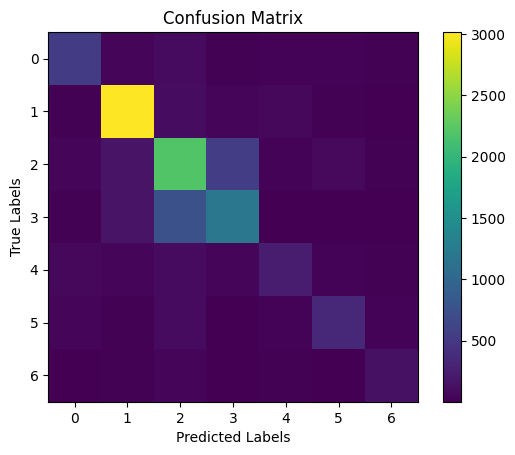

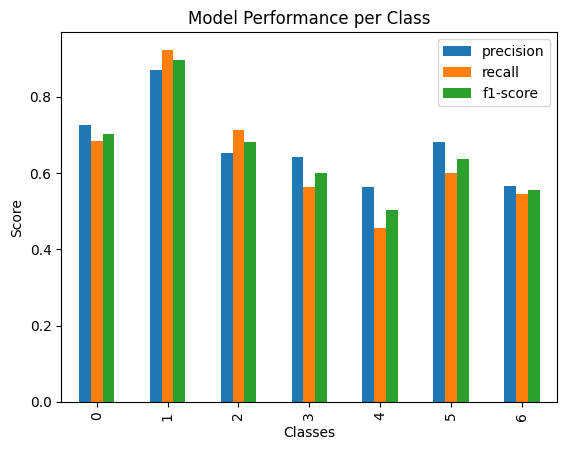

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.colorbar()
plt.show()

# ===== Precision / Recall / F1-score Graph =====
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")

plt.title("Model Performance per Class")
plt.xlabel("Classes")
plt.ylabel("Score")
plt.show()